# AWQ (W4A16) Quantization via `llm-compressor` \u2014 Full Pipeline

This notebook runs the **complete** AWQ quantization study on **Qwen2-1.5B**. AWQ (Activation-Aware Weight Quantization) is a post-training weight quantization method that identifies a small fraction of \u201csalient\u201d weight channels \u2014 those that correspond to large activation magnitudes \u2014 and protects them during quantization. Rather than keeping salient channels in higher precision (which would break hardware-efficient packed kernels), AWQ applies a per-channel scaling transformation that reduces the quantization error on those important channels before rounding. This allows it to use uniform INT4 packing throughout while preserving the weights that matter most.

This notebook uses **`llm-compressor`** (`vllm-project/llm-compressor`), the modern successor to the now-deprecated `AutoAWQ`. `llm-compressor` provides a clean `oneshot()` API with an `AWQModifier` that supports **selective quantization** via the `ignore` parameter \u2014 enabling all three ablation variants (`full_quant`, `attn_only_quant`, `mlp_only_quant`). Quantized checkpoints are saved in standard HuggingFace `safetensors` format, loadable by `transformers` without any special quantization library at inference time.

This notebook is **fully self-contained**: every function is defined inline, all dependencies are installed via `pip`, and there are **no imports from `src/`, `_shared.py`, or `config/default.yaml`**. It can be run standalone on Colab, Azure ML, or any GPU environment.

### Configuration

| Parameter | Value |
|-----------|-------|
| **Model** | `Qwen/Qwen2-1.5B` (1.5 B parameters, 28 transformer layers) |
| **Precision** | W4A16 \u2014 4-bit weights, 16-bit activations (asymmetric) |
| **Scheme** | `W4A16_ASYM` \u2014 asymmetric 4-bit weight quantization with 16-bit activations |
| **Calibration** | 512 samples from WikiText-2 (train split), each 2048 tokens, seed 42 |
| **Library** | `llm-compressor` via `oneshot()` + `AWQModifier` \u2014 prebuilt wheels, no compilation |

### Ablation Variants

Selective quantization is achieved via the `ignore` parameter of `AWQModifier`, which accepts a list of module-name regex patterns to **exclude** from quantization (keep in FP16):

- **`full_quant`** \u2014 quantize every Linear layer (attention + MLP projections)
- **`attn_only_quant`** \u2014 quantize only the attention projections (`q_proj`, `k_proj`, `v_proj`, `o_proj`); MLP layers remain in FP16
- **`mlp_only_quant`** \u2014 quantize only the MLP projections (`gate_proj`, `up_proj`, `down_proj`); attention layers remain in FP16

These variants allow us to isolate which module family is more sensitive to 4-bit quantization.

### Evaluation Strategy

All evaluation is done via **HuggingFace `transformers`** natively (`model.generate()` and teacher-forcing), with **no vLLM dependency at eval time**. This ensures the notebook runs on any single-GPU setup without needing vLLM\u2019s tensor-parallel infrastructure for evaluation.

### Notebook Sections

| # | Section | What It Does |
|---|---------|-------------|
| 1 | **Setup** | Install dependencies, build config dict, define all helper functions inline |
| 2 | **FP16 Baseline + Calibration** | Download and cache the FP16 reference model; build and cache the calibration corpus for reproducibility |
| 3 | **Quantization** | Run `llm-compressor` `oneshot()` with `AWQModifier` for each of the 3 ablation variants, saving checkpoints to `artifacts/awq_w4_g128/<variant>/` |
| 4 | **Evaluation** | For each artifact, measure perplexity (teacher-forcing on WikiText-2 test), GSM8K accuracy (8-shot), MATH accuracy (Level-5 competition problems), ARC-Challenge accuracy (0-shot MC), GPQA-Diamond accuracy (0-shot MC), deployment throughput (tok/s, ms/tok, peak VRAM), and checkpoint size (bytes/param) |
| 5 | **Ablation Study** | Compute the composite score `0.25*(GSM8K + MATH + ARC + GPQA)` per variant, then derive `delta_attn` and `delta_mlp` to determine which module family degrades accuracy more when quantized \u2014 visualized as a grouped bar chart |
| 6 | **Layer Diagnostics** | Run a fixed probe batch (32 sequences x 256 tokens) through both FP16 and each AWQ artifact with forward hooks, collecting per-layer activation percentiles (p50/p90/p99/p99.9/max), per-layer output MSE, and logit-level metrics (KL divergence, cosine similarity, top-1/top-5 agreement) |
| 7 | **Accuracy vs Bandwidth** | Scatter plot of composite score vs actual bytes/param \u2014 identifies the efficiency \u201csweet spot\u201d where accuracy loss is minimal relative to storage savings |
| 8 | **Deployment Metrics** | Three-panel scatter: score vs tokens/sec, ms/token, and peak VRAM \u2014 shows whether bandwidth gains translate to real inference speedups |
| 9 | **Layer MSE Heatmap** | Heatmap of per-layer MSE (transformer layer index vs module family), revealing which layers accumulate the most quantization error |
| 10 | **Summary** | Consolidated results table with all metrics per variant |

---
## 1. Setup

Install all required packages (Colab-compatible) and define every function
inline so this notebook is fully self-contained. Uses `llm-compressor` for
AWQ quantization and `transformers` for all evaluation — **no vLLM needed
at eval time, no compilation required**.

In [ ]:
!pip install -q torch transformers accelerate llmcompressor datasets evaluate \
    pandas pyarrow matplotlib seaborn pyyaml safetensors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 135.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.7 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import logging
import math
import os
import re
import subprocess
import sys
import tempfile
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Sequence
from tqdm import tqdm
from itertools import product

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")
logger = logging.getLogger("awq_notebook")
sns.set_theme(style="whitegrid", font_scale=1.1)

PROJECT_ROOT = Path.cwd().resolve()
print(f"Working directory: {PROJECT_ROOT}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE'}")

Working directory: /content
GPU: NVIDIA L4


In [ ]:
# ════════════════════════════════════════════════════════════════
# Inline configuration (replaces config/default.yaml)
# ════════════════════════════════════════════════════════════════

def _resolve_paths(cfg):
    paths = cfg.get("paths", {})
    for key in ("artifacts_dir", "results_dir", "calibration_dir", "plots_dir"):
        if key in paths and not Path(paths[key]).is_absolute():
            paths[key] = str(PROJECT_ROOT / paths[key])

cfg = {
    "base_model": "Qwen/Qwen2-1.5B",
    "calibration": {
        "dataset": "wikitext",
        "dataset_name": "wikitext-2-raw-v1",
        "split": "train",
        "num_samples": 512,
        "max_length": 2048,
        "seed": 42,
    },
    "quant_configs": [
        {"method": "gptq", "bits": 4, "group_size": 128, "desc_act": False},
        {"method": "awq",  "bits": 4, "group_size": 128, "zero_point": True, "version": "GEMM"},
        {"method": "rtn",  "bits": 8, "per_channel": True},
    ],
    "ablation_variants": ["full_quant", "attn_only_quant", "mlp_only_quant"],
    "eval": {
        "perplexity": {
            "dataset": "wikitext", "dataset_name": "wikitext-2-raw-v1",
            "split": "test", "max_length": 512, "stride": 256,
            "max_eval_tokens": 131072,
        },
        # "gsm8k":          {"num_fewshot": 8, "num_samples": 300, "max_new_tokens": 256},
        # "math":           {"num_samples": 500, "max_new_tokens": 1024},
        # "arc_challenge":  {"num_samples": 500, "max_new_tokens": 5},
        # "gpqa":           {"num_samples": 10, "max_new_tokens": 5},
        "gsm8k":          {"num_fewshot": 8, "num_samples": 20, "max_new_tokens": 256},
        "math":           {"num_samples": 10, "max_new_tokens": 256},
        "arc_challenge":  {"num_samples": 500, "max_new_tokens": 5},
        "gpqa":           {"num_samples": 10, "max_new_tokens": 5},
    },
    "accuracy_weights": {"gsm8k": 0.33, "math": 0.33, "arc_challenge": 0.34, "gpqa": 0.0},
    "deployment_benchmark": {
        "prompt_lengths": [128], # 512, 1024],
        "generation_lengths": [128], # 256],
        "batch_size": 1, "warmup_iters": 2, "bench_iters": 5,
    },
    "paths": {
        "artifacts_dir": "artifacts",
        "results_dir": "results",
        "calibration_dir": "calibration_data",
        "plots_dir": "results/plots",
    },
}
_resolve_paths(cfg)

METHOD = "awq"
VARIANTS = ["full_quant", "attn_only_quant", "mlp_only_quant"]

print(f"Base model : {cfg['base_model']}")
print(f"Method     : {METHOD}")
print(f"Variants   : {VARIANTS}")

Base model : Qwen/Qwen2-1.5B
Method     : awq
Variants   : ['full_quant', 'attn_only_quant', 'mlp_only_quant']


In [ ]:
# ════════════════════════════════════════════════════════════════
# Module utilities — selective quantization helpers
# ════════════════════════════════════════════════════════════════

ATTN_PATTERN = re.compile(r"self_attn\.(q|k|v|o)_proj")
MLP_PATTERN  = re.compile(r"mlp\.(gate|up|down)_proj")

@dataclass
class ModuleClassification:
    attn:  list[str] = field(default_factory=list)
    mlp:   list[str] = field(default_factory=list)
    other: list[str] = field(default_factory=list)
    @property
    def all_linear(self) -> list[str]:
        return self.attn + self.mlp + self.other

def classify_linear_modules(model: nn.Module) -> ModuleClassification:
    cls = ModuleClassification()
    for name, module in model.named_modules():
        if not isinstance(module, nn.Linear):
            continue
        if ATTN_PATTERN.search(name):   cls.attn.append(name)
        elif MLP_PATTERN.search(name):  cls.mlp.append(name)
        else:                           cls.other.append(name)
    return cls


def build_skip_modules(classification: ModuleClassification, variant: str) -> list[str]:
    if variant == "full_quant":
        return []
    if variant == "attn_only_quant":
        return classification.mlp + classification.other
    if variant == "mlp_only_quant":
        return classification.attn + classification.other
    raise ValueError(f"Unknown ablation variant: {variant}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# Calibration data
# ════════════════════════════════════════════════════════════════

def get_calibration_data(cfg, tokenizer=None):
    cal_cfg = cfg["calibration"]
    cache_dir = Path(cfg["paths"]["calibration_dir"])
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"calibration_{cal_cfg['num_samples']}.pt"
    if cache_path.exists():
        return torch.load(cache_path, weights_only=False)
    if tokenizer is None:
        tokenizer = AutoTokenizer.from_pretrained(cfg["base_model"], trust_remote_code=True)
    ds = load_dataset(cal_cfg["dataset"], cal_cfg["dataset_name"], split=cal_cfg["split"])
    all_text = "\n\n".join(t for t in ds["text"] if t.strip())
    rng = torch.Generator().manual_seed(cal_cfg["seed"])
    max_len = cal_cfg["max_length"]
    encoded = tokenizer(all_text, return_tensors="pt")
    total_tokens = encoded.input_ids.shape[1]
    samples = []
    starts = torch.randint(0, total_tokens - max_len, (cal_cfg["num_samples"],), generator=rng)
    for start in starts:
        end = start + max_len
        input_ids = encoded.input_ids[:, start:end]
        samples.append({"input_ids": input_ids, "attention_mask": torch.ones_like(input_ids)})
    torch.save(samples, cache_path)
    return samples

In [ ]:
# ════════════════════════════════════════════════════════════════
# Checkpoint size
# ════════════════════════════════════════════════════════════════

def bytes_per_param_from_safetensors(checkpoint_dir):
    checkpoint_dir = Path(checkpoint_dir)
    st_files = list(checkpoint_dir.glob("*.safetensors"))
    if not st_files:
        bin_files = list(checkpoint_dir.glob("*.bin")) + list(checkpoint_dir.glob("*.pt"))
        if not bin_files:
            logger.warning("No checkpoint files found in %s", checkpoint_dir); return 0.0
        total_bytes = total_params = 0
        for p in bin_files:
            sd = torch.load(str(p), map_location="cpu", weights_only=True)
            for t in sd.values():
                if hasattr(t, "numel"): total_bytes += t.numel() * t.element_size(); total_params += t.numel()
        return total_bytes / max(total_params, 1)
    try:
        from safetensors import safe_open
    except ImportError:
        return 0.0
    total_bytes = total_params = 0
    for p in st_files:
        with safe_open(str(p), framework="pt") as f:
            for key in f.keys():
                t = f.get_tensor(key)
                dtype = t.dtype
                numel = t.numel()
                # AWQ packs 4x INT4 into INT32 — real param count is 4x the tensor numel
                if dtype == torch.int32 and "weight" in key:
                    total_bytes += numel * 4        # 4 bytes per int32
                    total_params += numel * 8       # 8 x int4 values packed per int32
                else:
                    total_bytes += numel * t.element_size()
                    total_params += numel
    if total_params == 0: return 0.0
    bpp = total_bytes / total_params
    logger.info("Checkpoint %s: %.2f GB, %d params, %.3f bytes/param", checkpoint_dir.name, total_bytes/1e9, total_params, bpp)
    return bpp

In [ ]:
# ════════════════════════════════════════════════════════════════
# AWQ quantization via llm-compressor (oneshot + AWQModifier)
# ════════════════════════════════════════════════════════════════

# MLP_MODULES = ["gate_proj", "up_proj", "down_proj"]
# ATTN_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

IGNORE_FOR_ATTN_ONLY = [
    r"re:.*post_attention_layernorm",   # scaling anchor for MLP — skip it
    r"re:.*mlp\.(gate|up|down)_proj",  # MLP projections — keep in FP16
]

IGNORE_FOR_MLP_ONLY = [
    r"re:.*input_layernorm",            # scaling anchor for attn — skip it
    r"re:.*self_attn\.(q|k|v|o)_proj", # attn projections — keep in FP16
]

def _build_ignore_list(variant):
    """Build the ignore list for AWQModifier based on ablation variant.

    The ignore list tells llm-compressor which modules to SKIP (keep in FP16).
    We always ignore lm_head.
    """
    base_ignore = ["lm_head"]
    if variant == "full_quant":
        return base_ignore
    if variant == "attn_only_quant":
        return base_ignore + IGNORE_FOR_ATTN_ONLY
    if variant == "mlp_only_quant":
        return base_ignore + IGNORE_FOR_MLP_ONLY
    raise ValueError(f"Unknown variant: {variant}")


def quantize_awq(cfg, variant="full_quant"):
    """Quantize the base model with AWQ via llm-compressor oneshot().

    Supports all three ablation variants via the AWQModifier ignore parameter.
    Saves the compressed checkpoint in standard HF safetensors format.
    """
    from llmcompressor import oneshot
    from llmcompressor.modifiers.awq import AWQModifier

    output_dir = Path(cfg["paths"]["artifacts_dir"]) / "awq_w4_g128" / variant
    output_dir.mkdir(parents=True, exist_ok=True)

    if (output_dir / "config.json").exists():
        logger.info("AWQ artifact already exists at %s — skipping.", output_dir)
        return output_dir

    tokenizer = AutoTokenizer.from_pretrained(
        cfg["base_model"], trust_remote_code=True,
    )

    logger.info("Loading base model for AWQ quantization (%s)…", variant)
    model = AutoModelForCausalLM.from_pretrained(
        cfg["base_model"], torch_dtype="auto", trust_remote_code=True,
    )

    ignore_list = _build_ignore_list(variant)
    logger.info("Variant %s: ignore = %s", variant, ignore_list)

    recipe = [
        AWQModifier(
            ignore=ignore_list,
            scheme="W4A16_ASYM",
            targets=["Linear"],
        ),
    ]

    cal_cfg = cfg["calibration"]
    ds = load_dataset(cal_cfg["dataset"], cal_cfg["dataset_name"], split=cal_cfg["split"])
    ds = ds.filter(lambda x: len(x["text"].strip()) > 0)

    def tokenize_fn(example):
        return tokenizer(
            example["text"],
            padding=False,
            max_length=cal_cfg["max_length"],
            truncation=True,
        )

    ds = ds.map(tokenize_fn, remove_columns=ds.column_names)

    logger.info(
        "Running AWQ oneshot with %d calibration samples…",
        cal_cfg["num_samples"],
    )
    oneshot(
        model=model,
        dataset=ds,
        recipe=recipe,
        max_seq_length=cal_cfg["max_length"],
        num_calibration_samples=cal_cfg["num_samples"],
    )

    logger.info("Saving AWQ checkpoint to %s", output_dir)
    model.save_pretrained(str(output_dir), save_compressed=True)
    tokenizer.save_pretrained(str(output_dir))

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return output_dir

In [ ]:
# ════════════════════════════════════════════════════════════════
# Evaluation functions  (all HuggingFace-native, no vLLM dependency)
# ════════════════════════════════════════════════════════════════

def _load_eval_model(model_path):
    """Load a model for evaluation — works for FP16 and llm-compressor AWQ checkpoints."""
    return AutoModelForCausalLM.from_pretrained(
        model_path, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True,
    )


def evaluate_perplexity(model_path, cfg, *, device="cuda", **_kw):
    ppl_cfg = cfg["eval"]["perplexity"]
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = _load_eval_model(model_path)
    model.eval()
    ds = load_dataset(ppl_cfg["dataset"], ppl_cfg["dataset_name"], split=ppl_cfg["split"])
    text = "\n\n".join(t for t in ds["text"] if t.strip())
    encodings = tokenizer(text, return_tensors="pt")
    max_len = ppl_cfg["max_length"]
    stride = ppl_cfg["stride"]
    max_eval_tokens = ppl_cfg.get("max_eval_tokens", 131072)
    seq_len = min(encodings.input_ids.size(1), max_eval_tokens)

    total_steps = (seq_len // stride) + 1
    nlls, prev_end = [], 0
    for begin in tqdm(range(0, seq_len, stride), total=total_steps, desc="Perplexity"):
        end = min(begin + max_len, seq_len)
        input_ids = encodings.input_ids[:, begin:end].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :max(0, prev_end - begin)] = -100
        with torch.no_grad():
            nlls.append(model(input_ids, labels=target_ids).loss)
        prev_end = end
        if end >= seq_len:
            break
    ppl = math.exp(torch.stack(nlls).mean().item())
    del model; torch.cuda.empty_cache()
    logger.info("Perplexity (%.0fk tokens): %.2f", seq_len / 1e3, ppl)
    return ppl


# ────────────────────────────────────────────────────────────────
# Shared generation helpers
# ────────────────────────────────────────────────────────────────

@torch.inference_mode()
def _build_prefix_cache(model, input_ids):
    out = model(input_ids, use_cache=True)
    return out.past_key_values


_ANSWER_RE = re.compile(r"####\s*(-?[\d,]+\.?\d*)")

def _extract_numeric_answer(text):
    m = _ANSWER_RE.search(text)
    if m:
        return float(m.group(1).replace(",", ""))
    nums = re.findall(r"-?[\d,]+\.?\d*", text)
    return float(nums[-1].replace(",", "")) if nums else None


_BOXED_RE = re.compile(r"\\boxed\{([^}]*)\}")

def _extract_boxed_answer(text):
    matches = _BOXED_RE.findall(text)
    return matches[-1].strip() if matches else None


def _normalize_math_answer(ans):
    if ans is None:
        return None
    ans = ans.strip()
    ans = ans.replace("\\$", "").replace(",", "").replace(" ", "")
    ans = ans.replace("\\frac", "frac").replace("\\dfrac", "frac")
    ans = ans.replace("\\left", "").replace("\\right", "")
    ans = ans.replace("\\text{", "").replace("\\mathrm{", "")
    ans = ans.rstrip("}")
    try:
        return str(float(ans))
    except ValueError:
        return ans.lower()


# ────────────────────────────────────────────────────────────────
# GSM8K  (8-shot, KV-cache prefix reuse, 300 samples)
# ────────────────────────────────────────────────────────────────

_GSM_PROMPT = "Question: {question}\nAnswer: Let's think step by step.\n"

# def evaluate_gsm8k(model_path, cfg, **_kw):
#     gsm_cfg = cfg["eval"]["gsm8k"]
#     n_shot = gsm_cfg.get("num_fewshot", 8)
#     num_samples = gsm_cfg.get("num_samples", 300)
#     max_new = gsm_cfg.get("max_new_tokens", 256)
#     tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
#     if tokenizer.pad_token is None:
#         tokenizer.pad_token = tokenizer.eos_token
#     model = _load_eval_model(model_path); model.eval()
#     ds = load_dataset("openai/gsm8k", "main", split="test")
#     ds = ds.shuffle(seed=42).select(range(min(num_samples, len(ds))))

#     exemplar_ds = load_dataset("openai/gsm8k", "main", split="train")
#     exemplars = exemplar_ds.shuffle(seed=42).select(range(n_shot))
#     prefix_text = ""
#     for ex in exemplars:
#         prefix_text += _GSM_PROMPT.format(question=ex["question"]) + ex["answer"] + "\n\n"

#     prefix_ids = tokenizer(prefix_text, return_tensors="pt").input_ids.to(model.device)
#     past_kv = _build_prefix_cache(model, prefix_ids)
#     prefix_len = prefix_ids.shape[-1]

#     correct = total = 0
#     for row in ds:
#         q_text = _GSM_PROMPT.format(question=row["question"])
#         q_ids = tokenizer(q_text, return_tensors="pt").input_ids.to(model.device)
#         position_ids = torch.arange(prefix_len, prefix_len + q_ids.shape[-1], device=model.device).unsqueeze(0)
#         with torch.inference_mode():
#             out_ids = model.generate(
#                 input_ids=q_ids,
#                 past_key_values=past_kv,
#                 position_ids=position_ids,
#                 use_cache=True,
#                 max_new_tokens=max_new,
#                 do_sample=False,
#                 pad_token_id=tokenizer.eos_token_id,
#             )
#         gen = tokenizer.decode(out_ids[0][q_ids.shape[-1]:], skip_special_tokens=True)
#         pred = _extract_numeric_answer(gen)
#         gold = _extract_numeric_answer(row["answer"])
#         if pred is not None and gold is not None and abs(pred - gold) < 1e-3:
#             correct += 1
#         total += 1
#     del model; torch.cuda.empty_cache()
#     acc = correct / max(total, 1)
#     logger.info("GSM8K accuracy: %.3f (%d/%d)", acc, correct, total)
#     return acc

def evaluate_gsm8k(model_path, cfg, **_kw):
    gsm_cfg = cfg["eval"]["gsm8k"]
    n_shot = gsm_cfg.get("num_fewshot", 8)
    num_samples = gsm_cfg.get("num_samples", 300)
    max_new = gsm_cfg.get("max_new_tokens", 256)
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = _load_eval_model(model_path); model.eval()
    ds = load_dataset("openai/gsm8k", "main", split="test")
    ds = ds.shuffle(seed=42).select(range(min(num_samples, len(ds))))

    exemplar_ds = load_dataset("openai/gsm8k", "main", split="train")
    exemplars = exemplar_ds.shuffle(seed=42).select(range(n_shot))
    prefix_text = ""
    for ex in exemplars:
        prefix_text += _GSM_PROMPT.format(question=ex["question"]) + ex["answer"] + "\n\n"

    correct = total = 0
    for row in tqdm(ds, total=len(ds), desc="GSM8K"):
        # just concatenate prefix + question directly, no KV cache tricks
        full_prompt = prefix_text + _GSM_PROMPT.format(question=row["question"])
        input_ids = tokenizer(
            full_prompt, return_tensors="pt",
            truncation=True, max_length=2048
        ).input_ids.to(model.device)
        with torch.inference_mode():
            out_ids = model.generate(
                input_ids=input_ids,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        gen = tokenizer.decode(out_ids[0][input_ids.shape[-1]:], skip_special_tokens=True)
        pred = _extract_numeric_answer(gen)
        gold = _extract_numeric_answer(row["answer"])
        if pred is not None and gold is not None and abs(pred - gold) < 1e-3:
            correct += 1
        total += 1
    del model; torch.cuda.empty_cache()
    acc = correct / max(total, 1)
    logger.info("GSM8K accuracy: %.3f (%d/%d)", acc, correct, total)
    return acc


# ────────────────────────────────────────────────────────────────
# MATH  (0-shot, 500 Level-5 problems, extract \boxed{} answer)
# ────────────────────────────────────────────────────────────────

_MATH_PROMPT = (
    "Solve the following math problem. "
    "Show your work and put your final answer in \\boxed{{}}.\n\n"
    "Problem: {problem}\n\nSolution:"
)

def evaluate_math(model_path, cfg, **_kw):
    math_cfg = cfg["eval"]["math"]
    num_samples = math_cfg.get("num_samples", 500)
    max_new = math_cfg.get("max_new_tokens", 1024)
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = _load_eval_model(model_path); model.eval()
    ds = load_dataset("lighteval/MATH-Hard", split="test")
    ds = ds.shuffle(seed=42).select(range(min(num_samples, len(ds))))

    correct = total = 0
    for row in tqdm(ds, total=len(ds), desc="MATH"):
        prompt = _MATH_PROMPT.format(problem=row["problem"])
        input_ids = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).input_ids.to(model.device)
        with torch.inference_mode():
            out_ids = model.generate(
                input_ids=input_ids,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        gen = tokenizer.decode(out_ids[0][input_ids.shape[-1]:], skip_special_tokens=True)
        pred = _normalize_math_answer(_extract_boxed_answer(gen))
        gold = _normalize_math_answer(_extract_boxed_answer(row["solution"]))
        if pred is not None and gold is not None and pred == gold:
            correct += 1
        total += 1
    del model; torch.cuda.empty_cache()
    acc = correct / max(total, 1)
    logger.info("MATH accuracy: %.3f (%d/%d)", acc, correct, total)
    return acc


# ────────────────────────────────────────────────────────────────
# ARC-Challenge  (0-shot MC, 500 samples, KV-cache not needed —
#                  short prompts, just batch)
# ────────────────────────────────────────────────────────────────

_ARC_CHOICES = ["A", "B", "C", "D", "E"]

def _format_arc_prompt(row):
    labels = row["choices"]["label"]
    texts  = row["choices"]["text"]
    prompt = row["question"] + "\n"
    for lbl, txt in zip(labels, texts):
        prompt += f"{lbl}. {txt}\n"
    prompt += "Answer:"
    return prompt, labels

def evaluate_arc_challenge(model_path, cfg, **_kw):
    arc_cfg = cfg["eval"]["arc_challenge"]
    num_samples = arc_cfg.get("num_samples", 500)
    max_new = arc_cfg.get("max_new_tokens", 5)
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = _load_eval_model(model_path); model.eval()
    ds = load_dataset("allenai/ai2_arc", "ARC-Challenge", split="test")
    ds = ds.shuffle(seed=42).select(range(min(num_samples, len(ds))))

    correct = total = 0
    for row in tqdm(ds, total=len(ds), desc="ARC-Challenge"):
        prompt, labels = _format_arc_prompt(row)
        input_ids = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).input_ids.to(model.device)
        with torch.inference_mode():
            out_ids = model.generate(
                input_ids=input_ids,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        gen = tokenizer.decode(out_ids[0][input_ids.shape[-1]:], skip_special_tokens=True).strip()
        pred_letter = gen.split()[0].strip().rstrip(".") if gen.split() else ""
        gold = row["answerKey"]
        if pred_letter.upper() == gold.upper():
            correct += 1
        total += 1
    del model; torch.cuda.empty_cache()
    acc = correct / max(total, 1)
    logger.info("ARC-Challenge accuracy: %.3f (%d/%d)", acc, correct, total)
    return acc


# ────────────────────────────────────────────────────────────────
# GPQA  (0-shot MC, full diamond split ~198 Qs, shuffled choices)
# ────────────────────────────────────────────────────────────────

def _format_gpqa_prompt(row, rng):
    correct = row["Correct Answer"]
    wrong = [row["Incorrect Answer 1"], row["Incorrect Answer 2"], row["Incorrect Answer 3"]]
    options = [correct] + wrong
    rng.shuffle(options)
    correct_idx = options.index(correct)
    letters = ["A", "B", "C", "D"]
    prompt = row["Question"] + "\n"
    for lbl, opt in zip(letters, options):
        prompt += f"{lbl}. {opt}\n"
    prompt += "Answer:"
    return prompt, letters[correct_idx]

def evaluate_gpqa(model_path, cfg, **_kw):
    gpqa_cfg = cfg["eval"]["gpqa"]
    max_new = gpqa_cfg.get("max_new_tokens", 5)
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = _load_eval_model(model_path); model.eval()
    ds = load_dataset("Idavidrein/gpqa", "gpqa_diamond", split="train")
    num_samples = gpqa_cfg.get("num_samples", len(ds))
    ds = ds.select(range(min(num_samples, len(ds))))

    import random
    rng = random.Random(42)

    correct = total = 0
    for row in tqdm(ds, total=len(ds), desc="GPQA"):
        prompt, gold_letter = _format_gpqa_prompt(row, rng)
        input_ids = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4096).input_ids.to(model.device)
        with torch.inference_mode():
            out_ids = model.generate(
                input_ids=input_ids,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        gen = tokenizer.decode(out_ids[0][input_ids.shape[-1]:], skip_special_tokens=True).strip()
        pred_letter = gen.split()[0].strip().rstrip(".") if gen.split() else ""
        if pred_letter.upper() == gold_letter.upper():
            correct += 1
        total += 1
    del model; torch.cuda.empty_cache()
    acc = correct / max(total, 1)
    logger.info("GPQA-Diamond accuracy: %.3f (%d/%d)", acc, correct, total)
    return acc


# ────────────────────────────────────────────────────────────────
# Deployment benchmark  (multi-prompt sweep)
# ────────────────────────────────────────────────────────────────

@dataclass
class BenchmarkResult:
    tokens_per_sec: float
    ms_per_token: float
    peak_vram_gb: float
    prompt_length: int
    generation_length: int


def benchmark_throughput(model_path, cfg, **_kw):
    bc = cfg["deployment_benchmark"]
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = _load_eval_model(model_path); model.eval()

    prompt_lengths = bc.get("prompt_lengths", [128, 512, 1024])
    gen_lengths = bc.get("generation_lengths", [128, 256])
    results = []

    for plen, glen in tqdm(list(product(prompt_lengths, gen_lengths)), desc="Benchmark"):
        dummy = "Hello " * (plen // 2)
        inputs = tokenizer(dummy, return_tensors="pt", truncation=True, max_length=plen).to(model.device)
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        for _ in range(bc["warmup_iters"]):
            with torch.no_grad():
                model.generate(**inputs, max_new_tokens=glen, do_sample=False)
        total_tokens = 0
        start = time.perf_counter()
        for _ in range(bc["bench_iters"]):
            with torch.no_grad():
                out_ids = model.generate(**inputs, max_new_tokens=glen, do_sample=False)
            total_tokens += out_ids.shape[1] - inputs["input_ids"].shape[1]
        elapsed = time.perf_counter() - start
        tok_s = total_tokens / elapsed
        peak = torch.cuda.max_memory_allocated() / (1024**3) if torch.cuda.is_available() else 0.0
        r = BenchmarkResult(
            tokens_per_sec=tok_s,
            ms_per_token=(elapsed / total_tokens) * 1000,
            peak_vram_gb=peak,
            prompt_length=plen,
            generation_length=glen,
        )
        results.append(r)
        logger.info(
            "Bench prompt=%d gen=%d: %.1f tok/s, %.2f ms/tok, %.2f GB",
            plen, glen, tok_s, r.ms_per_token, peak,
        )

    del model; torch.cuda.empty_cache()
    return results  # return all, not just best


def summarize_benchmark(results):
    """Average metrics across all prompt/gen combinations."""
    tok_s = sum(r.tokens_per_sec for r in results) / len(results)
    ms    = sum(r.ms_per_token for r in results) / len(results)
    vram  = max(r.peak_vram_gb for r in results)  # take peak VRAM as worst case
    return {
        "tok_s": tok_s,
        "ms_per_token": ms,
        "peak_vram_gb": vram,
    }

In [ ]:
# ════════════════════════════════════════════════════════════════
# Layer diagnostics
# ════════════════════════════════════════════════════════════════

@dataclass
class LayerStats:
    method: str; variant: str; layer_idx: int; module_family: str
    module_name: str; mse: float; p50: float; p90: float; p99: float; p99_9: float; act_max: float

@dataclass
class LogitDiagnostics:
    method: str; variant: str; kl_div: float; cosine_sim: float
    top1_agreement: float; top5_agreement: float

def _module_family(name):
    if ATTN_PATTERN.search(name): return "attn"
    if MLP_PATTERN.search(name): return "mlp"
    return "other"

def _layer_index(name):
    m = re.search(r"layers\.(\d+)\.", name)
    return int(m.group(1)) if m else -1

def _activation_percentiles(tensor):
    flat = tensor.float().abs().flatten()
    if flat.numel() == 0:
        return {"p50": 0, "p90": 0, "p99": 0, "p99_9": 0, "act_max": 0}

    # subsample if too large for torch.quantile (limit is 2^24)
    max_elements = 2**24
    if flat.numel() > max_elements:
        idx = torch.randperm(flat.numel())[:max_elements]
        flat = flat[idx]

    q = torch.quantile(flat, torch.tensor([0.50, 0.90, 0.99, 0.999], device=flat.device))
    return {"p50": q[0].item(), "p90": q[1].item(), "p99": q[2].item(), "p99_9": q[3].item(), "act_max": flat.max().item()}

class _HookCollector:
    def __init__(self): self.data = {}; self._handles = []
    def register(self, model):
        for name, mod in model.named_modules():
            if isinstance(mod, nn.Linear) and _module_family(name) != "other":
                self._handles.append(mod.register_forward_hook(self._make_hook(name)))
    def _make_hook(self, name):
        def hook(mod, inp, out):
            x = inp[0] if isinstance(inp, tuple) else inp
            self.data[name] = {"input": x.detach().cpu(), "output": out.detach().cpu()}
        return hook
    def remove(self):
        for h in self._handles: h.remove()
        self._handles.clear()

def _load_model(path, **_kw):
    return AutoModelForCausalLM.from_pretrained(
        path, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True,
    )

def _compute_logit_diagnostics(fp16_logits, q_logits, method, variant):
    fp = fp16_logits.float().flatten(0, 1); qp = q_logits.float().flatten(0, 1)
    log_p = F.log_softmax(fp, dim=-1); p = log_p.exp()
    log_q = F.log_softmax(qp, dim=-1)
    kl = F.kl_div(log_q, p, reduction="batchmean", log_target=False).item()
    cos = F.cosine_similarity(fp, qp, dim=-1).mean().item()
    top1_agree = (fp.argmax(-1) == qp.argmax(-1)).float().mean().item()
    t5f, t5q = fp.topk(5, dim=-1).indices, qp.topk(5, dim=-1).indices
    top5 = sum(len(set(a.tolist()) & set(b.tolist())) for a, b in zip(t5f, t5q)) / (t5f.size(0) * 5)
    return LogitDiagnostics(method=method, variant=variant, kl_div=kl, cosine_sim=cos, top1_agreement=top1_agree, top5_agreement=top5)

def run_layer_diagnostics(fp16_path, quant_path, cfg, method, variant, *, probe_seqs=4, probe_len=64, device="cuda", **_kw):
    tokenizer = AutoTokenizer.from_pretrained(fp16_path, trust_remote_code=True)
    cal = get_calibration_data(cfg, tokenizer)
    input_ids = torch.cat([s["input_ids"][:, :probe_len] for s in cal[:probe_seqs]], dim=0).to(device)

    fp16_model = _load_model(fp16_path); fp16_model.eval()
    fp16_hooks = _HookCollector(); fp16_hooks.register(fp16_model)
    with torch.no_grad():
        fp16_out = fp16_model(input_ids)
    fp16_logits = fp16_out.logits.detach().cpu()
    fp16_data = dict(fp16_hooks.data); fp16_hooks.remove()
    del fp16_model; torch.cuda.empty_cache()

    q_model = _load_model(quant_path); q_model.eval()
    q_hooks = _HookCollector(); q_hooks.register(q_model)
    with torch.no_grad():
        q_out = q_model(input_ids)
    q_logits = q_out.logits.detach().cpu()
    q_data = dict(q_hooks.data); q_hooks.remove()
    del q_model; torch.cuda.empty_cache()

    stats = []
    for name in sorted(set(fp16_data) & set(q_data)):
        mse = F.mse_loss(q_data[name]["output"].float(), fp16_data[name]["output"].float()).item()
        act = _activation_percentiles(fp16_data[name]["input"])
        stats.append(LayerStats(method=method, variant=variant, layer_idx=_layer_index(name),
                                module_family=_module_family(name), module_name=name, mse=mse, **act))
    logit_diag = _compute_logit_diagnostics(fp16_logits, q_logits, method, variant)
    return stats, logit_diag

In [ ]:
# ════════════════════════════════════════════════════════════════
# Visualization
# ════════════════════════════════════════════════════════════════

def plot_accuracy_vs_bandwidth(eval_df, output_dir):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    for m in eval_df["method"].unique():
        sub = eval_df[eval_df["method"] == m]
        ax.scatter(sub["bytes_per_param_actual"], sub["score"], label=m.upper(), s=80, edgecolors="k", linewidths=0.5)
        for _, r in sub.iterrows():
            ax.annotate(r["variant"], (r["bytes_per_param_actual"], r["score"]), fontsize=7, ha="left", va="bottom")
    ax.set_xlabel("Effective bytes / parameter"); ax.set_ylabel("Composite accuracy score")
    ax.set_title("Accuracy vs. Bandwidth (Sweet-Spot Plot)"); ax.legend()
    fig.tight_layout(); fig.savefig(output_dir / "accuracy_vs_bandwidth.png", dpi=200); plt.close(fig)

def plot_accuracy_vs_deployment(eval_df, output_dir):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    metrics = [("tok_s", "Tokens / sec"), ("ms_per_token", "ms / token"), ("peak_vram_gb", "Peak VRAM (GB)")]
    available = [m for m in metrics if m[0] in eval_df.columns]
    if not available: return
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1: axes = [axes]
    for ax, (col, label) in zip(axes, available):
        for m in eval_df["method"].unique():
            sub = eval_df[eval_df["method"] == m]
            ax.scatter(sub[col], sub["score"], label=m.upper(), s=80, edgecolors="k", linewidths=0.5)
        ax.set_xlabel(label); ax.set_ylabel("Composite score"); ax.legend(fontsize=8)
    fig.suptitle("Accuracy vs. Deployment Metrics", fontsize=13)
    fig.tight_layout(); fig.savefig(output_dir / "accuracy_vs_deployment.png", dpi=200); plt.close(fig)

def plot_ablation_sensitivity(eval_df, output_dir, task_col="arc_challenge"):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for m in eval_df["method"].unique():
        sub = eval_df[eval_df["method"] == m]
        full = sub.loc[sub["variant"] == "full_quant", task_col]
        attn = sub.loc[sub["variant"] == "attn_only_quant", task_col]
        mlp  = sub.loc[sub["variant"] == "mlp_only_quant", task_col]
        if full.empty: continue
        fv = full.values[0]
        if not attn.empty: rows.append({"method": m.upper(), "family": "Attn projections", "delta": fv - attn.values[0]})
        if not mlp.empty:  rows.append({"method": m.upper(), "family": "MLP projections",  "delta": fv - mlp.values[0]})
    if not rows: logger.warning("Not enough ablation data for sensitivity plot."); return
    bar_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=bar_df, x="method", y="delta", hue="family", ax=ax)
    ax.set_ylabel("Score drop (full_quant - <family>_only)"); ax.set_xlabel("Quantization method")
    ax.set_title("Module-Family Sensitivity: MLP vs Attention")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    fig.tight_layout(); fig.savefig(output_dir / "ablation_sensitivity.png", dpi=200); plt.close(fig)

def plot_layer_mse_heatmap(layer_stats_df, output_dir):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    df = layer_stats_df if isinstance(layer_stats_df, pd.DataFrame) else pd.read_parquet(str(layer_stats_df))
    for m in df["method"].unique():
        sub = df[df["method"] == m]
        pivot = sub.pivot_table(index="layer_idx", columns="module_family", values="mse", aggfunc="mean")
        if pivot.empty: continue
        fig, ax = plt.subplots(figsize=(6, max(8, len(pivot) * 0.3)))
        import numpy as np

        pivot_log = np.log1p(pivot)
        sns.heatmap(pivot_log, ax=ax, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "MSE"})
        ax.set_title(f"Per-Layer MSE - {m.upper()}"); ax.set_ylabel("Transformer layer index"); ax.set_xlabel("Module family")
        fig.tight_layout(); fig.savefig(output_dir / f"layer_mse_{m}.png", dpi=200); plt.close(fig)

In [ ]:
# ════════════════════════════════════════════════════════════════
# Orchestration helpers
# ════════════════════════════════════════════════════════════════

def ensure_fp16(cfg):
    fp16_dir = Path(cfg["paths"]["artifacts_dir"]) / "fp16"
    fp16_dir.mkdir(parents=True, exist_ok=True)
    if (fp16_dir / "config.json").exists():
        logger.info("FP16 reference already cached at %s", fp16_dir)
        return fp16_dir
    logger.info("Saving FP16 reference to %s ...", fp16_dir)
    tok = AutoTokenizer.from_pretrained(cfg["base_model"], trust_remote_code=True)
    mdl = AutoModelForCausalLM.from_pretrained(cfg["base_model"], torch_dtype=torch.float16, trust_remote_code=True)
    mdl.save_pretrained(str(fp16_dir)); tok.save_pretrained(str(fp16_dir))
    del mdl
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return fp16_dir


def discover_artifacts(cfg, method):
    base = Path(cfg["paths"]["artifacts_dir"])
    found = []
    for md in sorted(base.iterdir()):
        if not md.is_dir() or md.name == "fp16":
            continue
        key = md.name.split("_")[0]
        if key != method:
            continue
        for vd in sorted(md.iterdir()):
            if not vd.is_dir() or not any(vd.iterdir()):
                continue
            found.append({"method": key, "variant": vd.name, "path": str(vd)})
    return found


def free_memory():
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


def evaluate_artifact(art, cfg, *, skip_tasks=None):
    print(f"Evaluating: {art}")
    skip = skip_tasks or set()
    weights = cfg["accuracy_weights"]
    row = {
        "method": art["method"],
        "variant": art["variant"],
        "bytes_per_param_actual": bytes_per_param_from_safetensors(art["path"]),
    }
    if "perplexity" not in skip:
        print("Running Perplexity")
        try:
            row["ppl"] = evaluate_perplexity(art["path"], cfg)
            print(f"Perplexity: {row['ppl']:.4f}")
        except Exception:
            logger.exception("Perplexity failed"); row["ppl"] = None
        free_memory()
    if "gsm8k" not in skip:
        print("Running GSM8K")
        try:
            row["gsm8k"] = evaluate_gsm8k(art["path"], cfg)
            print(f"GSM8K: {row['gsm8k']:.4f}")
        except Exception:
            logger.exception("GSM8K failed"); row["gsm8k"] = None
        free_memory()
    if "math" not in skip:
        print("Running Math")
        try:
            print("skipping math")
            # row["math"] = evaluate_math(art["path"], cfg)
            # print(f"Math: {row['math']:.4f}")
        except Exception:
            logger.exception("MATH failed"); row["math"] = None
        free_memory()
    if "arc_challenge" not in skip:
        print("Running ARC-Challenge")
        try:
            row["arc_challenge"] = evaluate_arc_challenge(art["path"], cfg)
            print(f"ARC-Challenge: {row['arc_challenge']:.4f}")
        except Exception:
            logger.exception("ARC-Challenge failed"); row["arc_challenge"] = None
        free_memory()
    if "gpqa" not in skip:
        print("Running GPQA")
        try:
            print("Skipping GPQA")
            # row["gpqa"] = evaluate_gpqa(art["path"], cfg)
        except Exception:
            logger.exception("GPQA failed"); row["gpqa"] = None
        free_memory()
    # metric_vals = {k: row.get(k) for k in weights}
    # if all(v is not None for v in metric_vals.values()):
    #     row["score"] = sum(weights[k] * metric_vals[k] for k in weights)
    #     print(f"Composite score: {row['score']:.4f}")
    # else:
    #     row["score"] = None
    row['score'] = 0.8 * row["arc_challenge"] + 0.2 * row["gsm8k"]
    if "benchmark" not in skip:
        print("Running Benchmark")
        try:
            results = benchmark_throughput(art["path"], cfg)
            summary = summarize_benchmark(results)
            row["tok_s"] = summary["tok_s"]
            row["ms_per_token"] = summary["ms_per_token"]
            row["peak_vram_gb"] = summary["peak_vram_gb"]
            print(f"Throughput: {row['tok_s']:.1f} tok/s")
            print(f"Latency: {row['ms_per_token']:.2f} ms/token")
            print(f"Peak VRAM: {row['peak_vram_gb']:.2f} GB")
        except Exception:
            logger.exception("Benchmark failed")
        free_memory()

    print(f"Row: {row}")
    return row


def evaluate_all(artifacts, cfg, *, skip_tasks=None): # Changed from None
    return pd.DataFrame([evaluate_artifact(a, cfg, skip_tasks=skip_tasks) for a in artifacts])


def run_all_diagnostics(artifacts, cfg):
    fp16_path = str(Path(cfg["paths"]["artifacts_dir"]) / "fp16")
    all_stats, all_logits = [], []
    for art in artifacts:
        logger.info("Diagnostics: %s / %s", art["method"], art["variant"])
        try:
            s, l = run_layer_diagnostics(fp16_path, art["path"], cfg, art["method"], art["variant"])
            all_stats.extend(s)
            all_logits.append(l)
        except Exception:
            logger.exception("Diagnostics failed for %s / %s", art["method"], art["variant"])
    stats_df = pd.DataFrame([asdict(s) for s in all_stats]) if all_stats else pd.DataFrame()
    return stats_df, [asdict(d) for d in all_logits]


def save_eval_results(eval_df, cfg, method):
    rd = Path(cfg["paths"]["results_dir"]); rd.mkdir(parents=True, exist_ok=True)
    out = rd / f"{method}_eval.jsonl"
    with open(out, "w") as f:
        for row in eval_df.to_dict(orient="records"):
            f.write(json.dumps(row) + "\n")
    logger.info("Saved %d rows to %s", len(eval_df), out)
    return out


def save_diagnostics(layer_stats_df, logit_diags, cfg, method):
    rd = Path(cfg["paths"]["results_dir"]); rd.mkdir(parents=True, exist_ok=True)
    pq = rd / f"{method}_layer_stats.parquet"
    if not layer_stats_df.empty:
        layer_stats_df.to_parquet(str(pq), index=False)
    jp = rd / f"{method}_logit_diagnostics.json"
    with open(jp, "w") as f:
        json.dump(logit_diags, f, indent=2)
    return pq, jp


def get_plots_dir(cfg, method):
    d = Path(cfg["paths"]["plots_dir"]) / method
    d.mkdir(parents=True, exist_ok=True)
    return d

print("All functions defined. Setup complete.")

All functions defined. Setup complete.


---
## 2. FP16 Baseline and Calibration Data

In [ ]:
fp16_dir = ensure_fp16(cfg)
print(f"FP16 checkpoint: {fp16_dir}")

tokenizer = AutoTokenizer.from_pretrained(cfg["base_model"], trust_remote_code=True)
get_calibration_data(cfg, tokenizer)
print("Calibration data ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2517232 > 32768). Running this sequence through the model will result in indexing errors


Calibration data ready.


---
## 3. AWQ Quantization

Quantize the base model with `llm-compressor` `oneshot()` + `AWQModifier`
(W4A16_ASYM) for each ablation variant:

- **full_quant** — quantize all Linear layers
- **attn_only_quant** — quantize only attention projections (q/k/v/o_proj)
- **mlp_only_quant** — quantize only MLP projections (gate/up/down_proj)

Selective quantization is achieved via the `ignore` parameter of
`AWQModifier`, which accepts module name patterns to exclude.

In [ ]:
for variant in VARIANTS:
    print(f"\n{'='*60}")
    print(f"Quantizing: AWQ / {variant}")
    print(f"{'='*60}")
    try:
        out = quantize_awq(cfg, variant=variant)
        print(f"  -> Saved to {out}")
    except Exception as e:
        print(f"  !! FAILED: {e}")

print("\nAWQ quantization complete.")

## Unzip Uploaded Models and Check

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import zipfile
zip_path = "/content/drive/MyDrive/artifacts.zip"  # adjust path if it's in a subfolder

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content")

print("Done!")
!find /content/artifacts -type d

Mounted at /content/drive
Done!
/content/artifacts
/content/artifacts/awq_w4_g128
/content/artifacts/awq_w4_g128/attn_only_quant
/content/artifacts/awq_w4_g128/full_quant
/content/artifacts/awq_w4_g128/mlp_only_quant


In [ ]:
def check_quantization(cfg):
    from safetensors import safe_open

    variants = ["full_quant", "attn_only_quant", "mlp_only_quant"]

    ATTN_KEYS = {"q_proj", "k_proj", "v_proj", "o_proj"}
    MLP_KEYS  = {"gate_proj", "up_proj", "down_proj"}

    def get_layer_info(checkpoint_dir):
        info = {}
        for f in Path(checkpoint_dir).glob("*.safetensors"):
            with safe_open(str(f), framework="pt") as sf:
                for key in sf.keys():
                    # quantized layers have weight_packed, unquantized have weight
                    if key.endswith("weight_packed") or key.endswith(".weight"):
                        t = sf.get_tensor(key)
                        info[key] = (t.dtype, t.numel(), key.endswith("weight_packed"))
        return info

    def classify_key(key):
        # normalize: remove _packed/_scale/_zero_point/_shape suffix
        base = key.replace("_packed", "").replace("_scale", "").replace("_zero_point", "").replace("_shape", "")
        for part in ATTN_KEYS:
            if part in base: return "attn"
        for part in MLP_KEYS:
            if part in base: return "mlp"
        return "other"

    def summarize(layer_info):
        if not layer_info:
            return False, 0.0
        # quantized if ALL layers have weight_packed (not plain .weight)
        quantized = all(is_packed for _, _, is_packed in layer_info.values())
        total_bytes = sum(
            (n * 4 // 2) if is_packed else (n * 2)  # int32-packed→4-bit, else bfloat16
            for _, n, is_packed in layer_info.values()
        )
        return quantized, total_bytes / (1024 ** 2)

    expected = {
        "full_quant":      (True,  True),
        "attn_only_quant": (True,  False),
        "mlp_only_quant":  (False, True),
    }

    all_passed = True
    for variant in variants:
        ckpt_dir = Path(cfg["paths"]["artifacts_dir"]) / "awq_w4_g128" / variant
        if not ckpt_dir.exists():
            print(f"[SKIP]  {variant} — checkpoint not found at {ckpt_dir}\n")
            continue

        all_info  = get_layer_info(ckpt_dir)
        attn_info = {k: v for k, v in all_info.items() if classify_key(k) == "attn"}
        mlp_info  = {k: v for k, v in all_info.items() if classify_key(k) == "mlp"}
        other_info = {k: v for k, v in all_info.items() if classify_key(k) == "other"}

        attn_quantized, attn_mb = summarize(attn_info)
        mlp_quantized,  mlp_mb  = summarize(mlp_info)
        _,              other_mb = summarize(other_info)
        total_mb = attn_mb + mlp_mb + other_mb

        want_attn, want_mlp = expected[variant]
        attn_ok = attn_quantized == want_attn
        mlp_ok  = mlp_quantized  == want_mlp
        passed  = attn_ok and mlp_ok
        all_passed = all_passed and passed

        status = "PASS" if passed else "FAIL"
        print(f"[{status}]  {variant}")
        print(f"       attn  quantized: {attn_quantized} (expected {want_attn}) {'✓' if attn_ok else '✗'}  — {attn_mb:.1f} MB")
        print(f"       mlp   quantized: {mlp_quantized}  (expected {want_mlp}) {'✓' if mlp_ok else '✗'}  — {mlp_mb:.1f} MB")
        print(f"       other (fp16):                                     — {other_mb:.1f} MB")
        print(f"       total:                                             — {total_mb:.1f} MB")
        if not passed:
            if not attn_ok:
                print(f"       attn sample dtypes: {list(attn_info.items())[:3]}")
            if not mlp_ok:
                print(f"       mlp  sample dtypes: {list(mlp_info.items())[:3]}")
        print()

    print("═" * 40)
    print("All checks passed ✓" if all_passed else "Some checks FAILED ✗ — see above")

check_quantization(cfg)

[PASS]  full_quant
       attn  quantized: True (expected True) ✓  — 36.8 MB
       mlp   quantized: True  (expected True) ✓  — 275.6 MB
       other (fp16):                                     — 445.3 MB
       total:                                             — 757.7 MB

[PASS]  attn_only_quant
       attn  quantized: True (expected True) ✓  — 36.8 MB
       mlp   quantized: False  (expected False) ✓  — 2205.0 MB
       other (fp16):                                     — 445.3 MB
       total:                                             — 2687.0 MB

[PASS]  mlp_only_quant
       attn  quantized: False (expected False) ✓  — 294.0 MB
       mlp   quantized: True  (expected True) ✓  — 275.6 MB
       other (fp16):                                     — 445.3 MB
       total:                                             — 1014.9 MB

════════════════════════════════════════
All checks passed ✓


---
## 4. Evaluation

For each AWQ artifact, run:
- **Perplexity** (teacher-forcing on WikiText-2 test, 128k tokens)
- **GSM8K** accuracy (8-shot, KV-cache prefix reuse, 300 samples)
- **MATH** accuracy (0-shot, Level-5 competition problems, 500 samples)
- **ARC-Challenge** accuracy (0-shot multiple-choice, 500 samples)
- **GPQA-Diamond** accuracy (0-shot multiple-choice, all 198 samples)
- **Deployment benchmark** (tok/s, ms/tok, peak VRAM across prompt lengths)
- **Checkpoint size** (actual bytes/param)

In [ ]:
artifacts = discover_artifacts(cfg, METHOD)
artifacts.insert(0, {"method": "awq", "variant": "baseline", "path": cfg["base_model"]})
print(artifacts)
print(f"Found {len(artifacts)} AWQ artifact(s):")
for a in artifacts:
    print(f"  {a['variant']:20s}  {a['path']}")

[{'method': 'awq', 'variant': 'baseline', 'path': 'Qwen/Qwen2-1.5B'}, {'method': 'awq', 'variant': 'attn_only_quant', 'path': '/content/artifacts/awq_w4_g128/attn_only_quant'}, {'method': 'awq', 'variant': 'full_quant', 'path': '/content/artifacts/awq_w4_g128/full_quant'}, {'method': 'awq', 'variant': 'mlp_only_quant', 'path': '/content/artifacts/awq_w4_g128/mlp_only_quant'}]
Found 4 AWQ artifact(s):
  baseline              Qwen/Qwen2-1.5B
  attn_only_quant       /content/artifacts/awq_w4_g128/attn_only_quant
  full_quant            /content/artifacts/awq_w4_g128/full_quant
  mlp_only_quant        /content/artifacts/awq_w4_g128/mlp_only_quant


In [ ]:
eval_df = evaluate_all(artifacts, cfg)
save_eval_results(eval_df, cfg, METHOD)
eval_df

Evaluating: {'method': 'awq', 'variant': 'baseline', 'path': 'Qwen/Qwen2-1.5B'}
Running Perplexity


Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 32768). Running this sequence through the model will result in indexing errors
Perplexity:  86%|████████▌ | 18/21 [00:00<00:00, 19.16it/s]


Perplexity: 12.3364
Running GSM8K


GSM8K: 100%|██████████| 20/20 [01:31<00:00,  4.58s/it]


GSM8K: 0.5500
Running Math
skipping math
Running ARC-Challenge


...

The tokenizer you are loading from '/content/artifacts/awq_w4_g128/mlp_only_quant' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 84it [00:00, 1658.09it/s]
ARC-Challenge: 100%|██████████| 500/500 [05:33<00:00,  1.50it/s]


ARC-Challenge: 0.6340
Running GPQA
Skipping GPQA
Running Benchmark


The tokenizer you are loading from '/content/artifacts/awq_w4_g128/mlp_only_quant' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 84it [00:00, 1669.56it/s]
Benchmark:   0%|          | 0/1 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Benchmark: 100%|██████████| 1/1 

Throughput: 7.5 tok/s
Latency: 133.45 ms/token
Peak VRAM: 6.28 GB
Row: {'method': 'awq', 'variant': 'mlp_only_quant', 'bytes_per_param_actual': 0.881000206180414, 'ppl': 12.68193496802397, 'gsm8k': 0.6, 'arc_challenge': 0.634, 'score': 0.6272, 'tok_s': 7.49333382096486, 'ms_per_token': 133.45194861093717, 'peak_vram_gb': 6.278116226196289}


,method,variant,bytes_per_param_actual,ppl,gsm8k,arc_challenge,score,tok_s,ms_per_token,peak_vram_gb
0,awq,baseline,0.000000,12.336393,0.55,0.658,0.6364,26.572435,37.632984,5.590814
1,awq,attn_only_quant,1.849290,12.545359,0.55,0.640,0.6220,11.676704,85.640604,5.711876
2,awq,full_quant,0.733754,13.016976,0.60,0.626,0.6208,5.302064,188.605806,6.377240
3,awq,mlp_only_quant,0.881000,12.681935,0.60,0.634,0.6272,7.493334,133.451949,6.278116


In [ ]:
order = ["baseline", "attn_only_quant", "mlp_only_quant", "full_quant"]
eval_df = eval_df.set_index("variant").loc[order].reset_index()

## Perplexity and Arc Accuracy

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# variants = eval_df["variant"]
# x = np.arange(len(variants))
# width = 0.5

# # ARC Challenge
# ax1.bar(x, eval_df["arc_challenge"], width, color=["#2196F3", "#4CAF50", "#FF9800"])
# ax1.set_xticks(x)
# ax1.set_xticklabels(variants, rotation=15, ha="right")
# ax1.set_ylabel("Accuracy")
# ax1.set_title("ARC-Challenge Accuracy by Variant")
# ax1.set_ylim(0.60, 0.66)  # zoom in to make differences visible
# for i, v in enumerate(eval_df["arc_challenge"]):
#     ax1.text(i, v + 0.0005, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

# # Perplexity (lower is better)
# ax2.bar(x, eval_df["ppl"], width, color=["#2196F3", "#4CAF50", "#FF9800"])
# ax2.set_xticks(x)
# ax2.set_xticklabels(variants, rotation=15, ha="right")
# ax2.set_ylabel("Perplexity (lower is better)")
# ax2.set_title("Perplexity by Variant")
# for i, v in enumerate(eval_df["ppl"]):
#     ax2.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

# fig.suptitle("Qwen2-1.5B AWQ Quantization — ARC & Perplexity", fontsize=13, fontweight="bold")
# fig.tight_layout()
# plt.show()

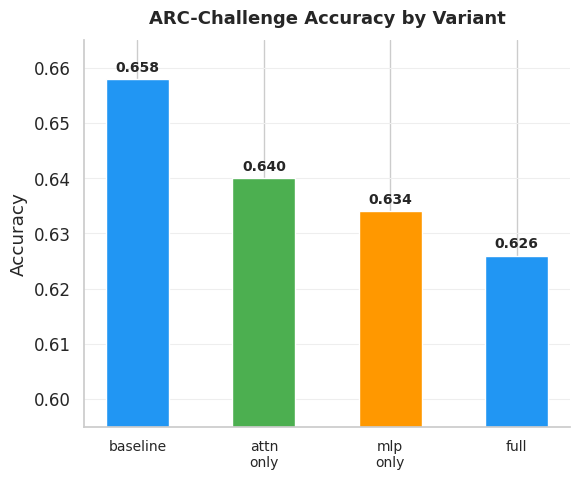

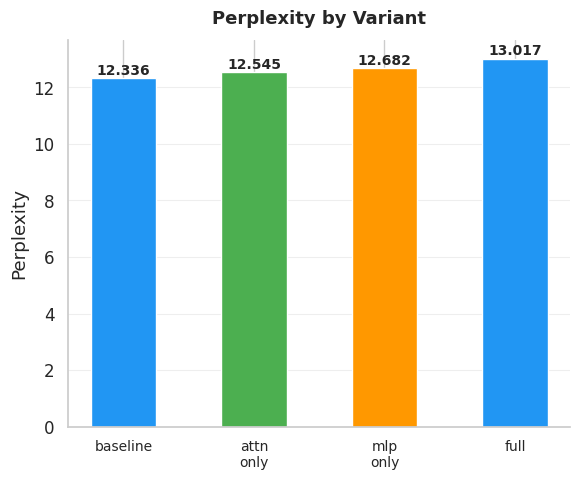

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

variant_labels = [v.replace("_quant", "").replace("_", "\n") for v in eval_df["variant"]]
x = np.arange(len(variant_labels))
COLORS = ["#2196F3", "#4CAF50", "#FF9800"]

# ── Plot 1: ARC-Challenge ──────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
bars = ax1.bar(x, eval_df["arc_challenge"], width=0.5, color=COLORS)
ax1.set_xticks(x)
ax1.set_xticklabels(variant_labels, fontsize=10)
ax1.set_ylabel("Accuracy")
ax1.set_title("ARC-Challenge Accuracy by Variant", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylim(0.595, 0.665)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
for bar, v in zip(bars, eval_df["arc_challenge"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.0008,
             f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
fig1.tight_layout()
plt.show()

# ── Plot 2: Perplexity ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
bars2 = ax2.bar(x, eval_df["ppl"], width=0.5, color=COLORS)
ax2.set_xticks(x)
ax2.set_xticklabels(variant_labels, fontsize=10)
ax2.set_ylabel("Perplexity")
ax2.set_title("Perplexity by Variant", fontsize=13, fontweight="bold", pad=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
for bar, v in zip(bars2, eval_df["ppl"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
             f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
fig2.tight_layout()
plt.show()

---
## 5. Ablation Study — MLP vs Attention Sensitivity

Compare the composite score across ablation variants to determine which
module family (MLP vs attention) is more sensitive to 4-bit AWQ
quantization.

- `delta_attn = score(full_quant) - score(attn_only_quant)`
- `delta_mlp  = score(full_quant) - score(mlp_only_quant)`

A **larger delta** means that family causes more degradation.

In [ ]:
def plot_ablation_sensitivity(eval_df, output_dir, task_col="arc_challenge"):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)

    variant_order = ["attn_only_quant", "mlp_only_quant", "full_quant"]
    labels = ["attn\nonly", "mlp\nonly", "full"]
    COLORS = ["#2196F3", "#4CAF50", "#FF9800"]
    x = np.arange(len(variant_order))

    rows = []
    for m in eval_df["method"].unique():
        sub = eval_df[eval_df["method"] == m]
        baseline = sub.loc[sub["variant"] == "baseline", task_col]
        if baseline.empty: logger.warning("No baseline row found for method %s", m); continue
        bv = baseline.values[0]
        for v in variant_order:
            val = sub.loc[sub["variant"] == v, task_col]
            rows.append(val.values[0] - bv if not val.empty else None)

    if not any(r is not None for r in rows):
        logger.warning("Not enough ablation data for sensitivity plot."); return

    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(x, rows, width=0.5, color=COLORS, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(f"{task_col} drop vs baseline")
    ax.set_title("Ablation Sensitivity vs FP16 Baseline", fontsize=13, fontweight="bold", pad=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.8, zorder=0)
    ax.axhline(0, color="#aaaaaa", linestyle="--", linewidth=0.8)
    for bar, v in zip(bars, rows):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.0005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    fig.tight_layout()
    fig.savefig(output_dir / "ablation_sensitivity.png", dpi=200)
    plt.show()

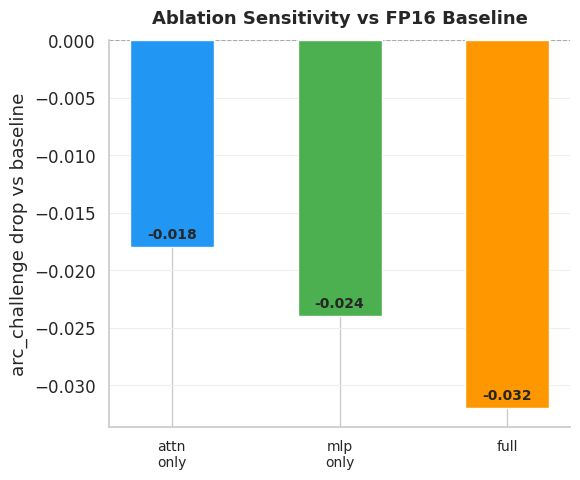

In [ ]:
from IPython.display import Image, display

plots_dir = get_plots_dir(cfg, METHOD)

plot_ablation_sensitivity(eval_df, plots_dir)

---
## 6. Layer Diagnostics

Run a fixed probe batch (32 sequences x 256 tokens) through both the
FP16 reference and the AWQ full_quant artifact, collecting:

- Per-layer activation percentiles (p50, p90, p99, p99.9, max)
- Per-layer output MSE (FP16 vs quantized)
- Logit-level KL divergence, cosine similarity, top-1/top-5 agreement

In [ ]:
layer_stats_df, logit_diags = run_all_diagnostics(artifacts, cfg)
save_diagnostics(layer_stats_df, logit_diags, cfg, METHOD)

print(f"Layer stats shape: {layer_stats_df.shape}")
print(f"Logit diagnostics: {len(logit_diags)} entries")

The tokenizer you are loading from '/content/artifacts/fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 112it [00:00, 1747.30it/s]
The tokenizer you are loading from '/content/artifacts/fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 196it [00:00, 1941.94it/s]
The tokenizer you are loading from '/content/artifacts/fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to in

Layer stats shape: (588, 11)
Logit diagnostics: 3 entries


In [ ]:
if logit_diags:
    display(pd.DataFrame(logit_diags))
else:
    print("No logit diagnostics available.")

,method,variant,kl_div,cosine_sim,top1_agreement,top5_agreement
0,awq,attn_only_quant,0.024468,0.997228,0.921875,0.914844
1,awq,full_quant,0.084732,0.991006,0.859375,0.848437
2,awq,mlp_only_quant,0.064581,0.993591,0.851562,0.871094


---
## 7. Accuracy vs Bandwidth Trade-off

Scatter plot of composite accuracy score vs actual bytes per parameter
for the AWQ full_quant variant.

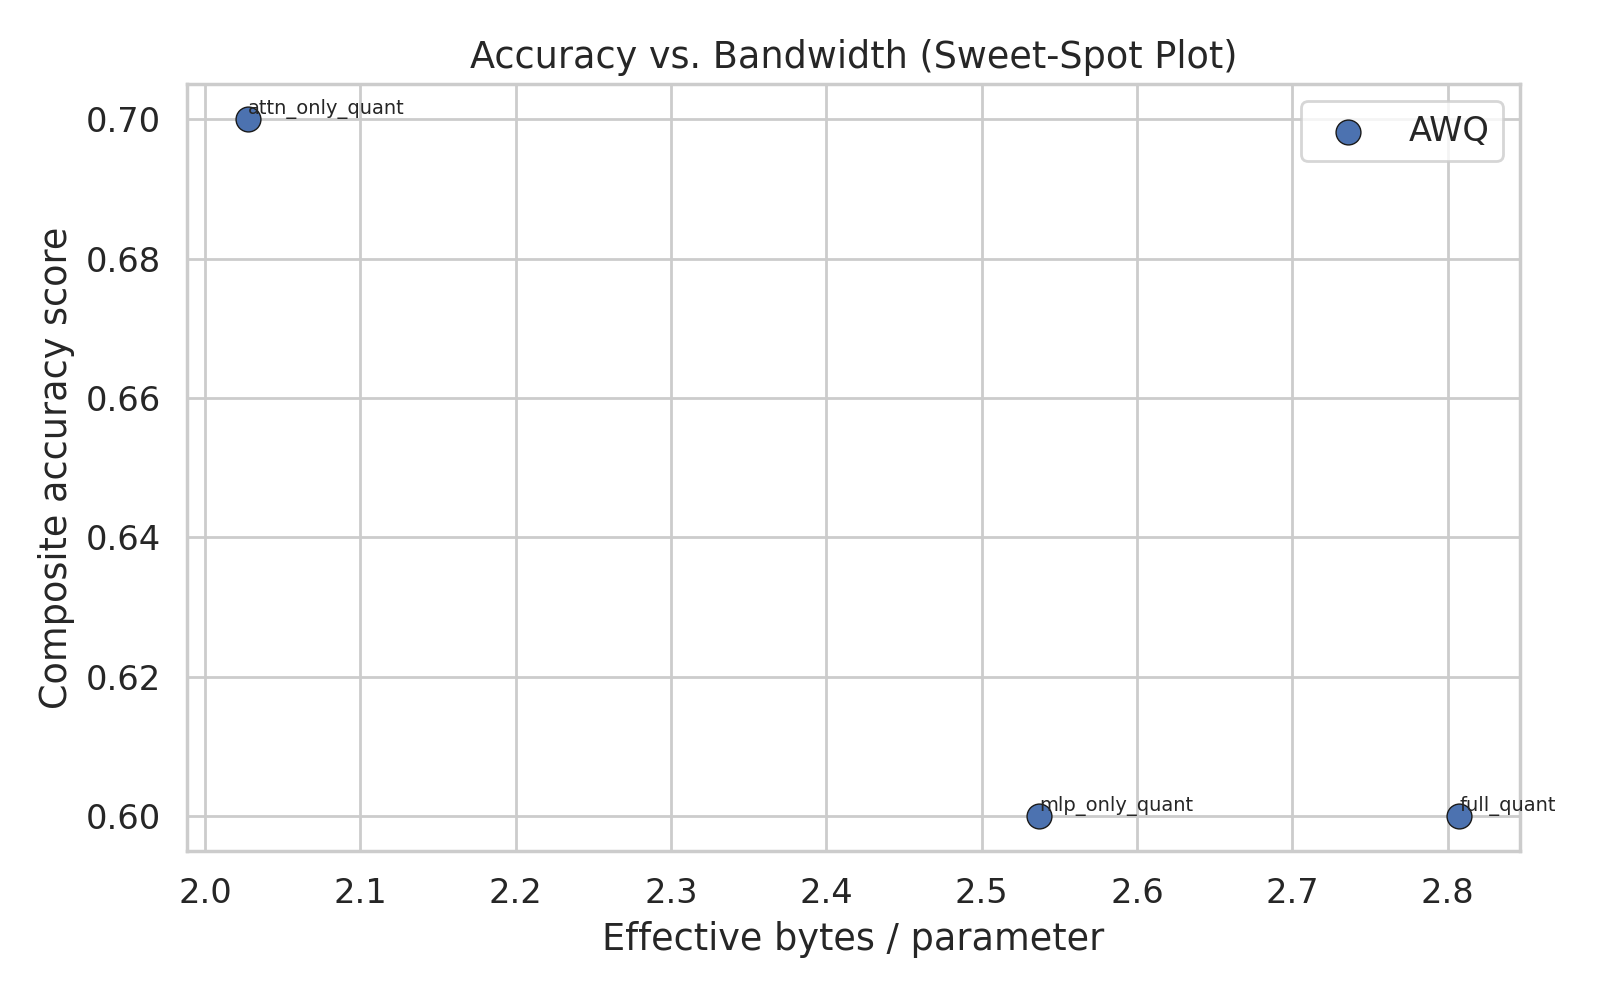

In [ ]:
plot_accuracy_vs_bandwidth(eval_df, plots_dir)

bw_png = plots_dir / "accuracy_vs_bandwidth.png"
if bw_png.exists():
    display(Image(filename=str(bw_png)))

---
## 8. Deployment Metrics

Scatter panels: composite score vs tokens/sec, ms/token, and peak VRAM.
Shows whether bandwidth savings translate into real deployment gains.

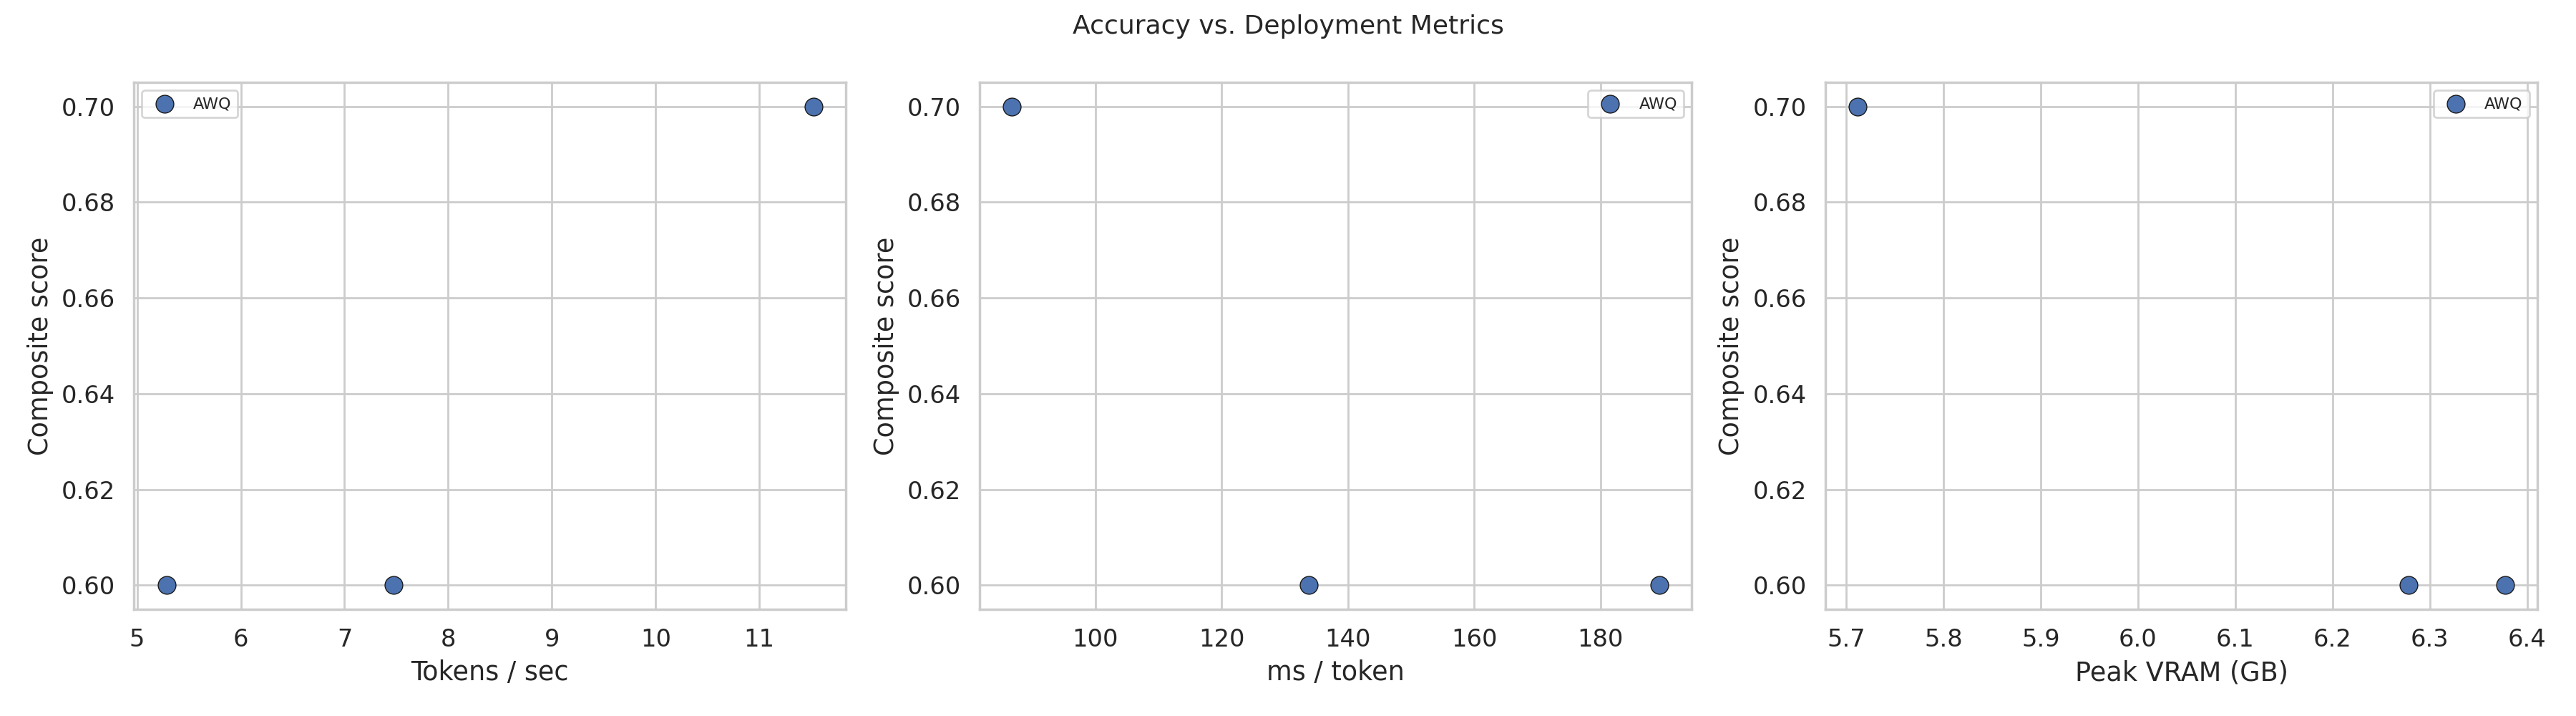

In [ ]:
plot_accuracy_vs_deployment(eval_df, plots_dir)

dep_png = plots_dir / "accuracy_vs_deployment.png"
if dep_png.exists():
    display(Image(filename=str(dep_png)))

---
## 9. Layer MSE Heatmap

Heatmap with transformer layer index on the y-axis and module family
(attn/mlp) on the x-axis, coloured by mean MSE. Identifies which layers
accumulate the most quantization error.

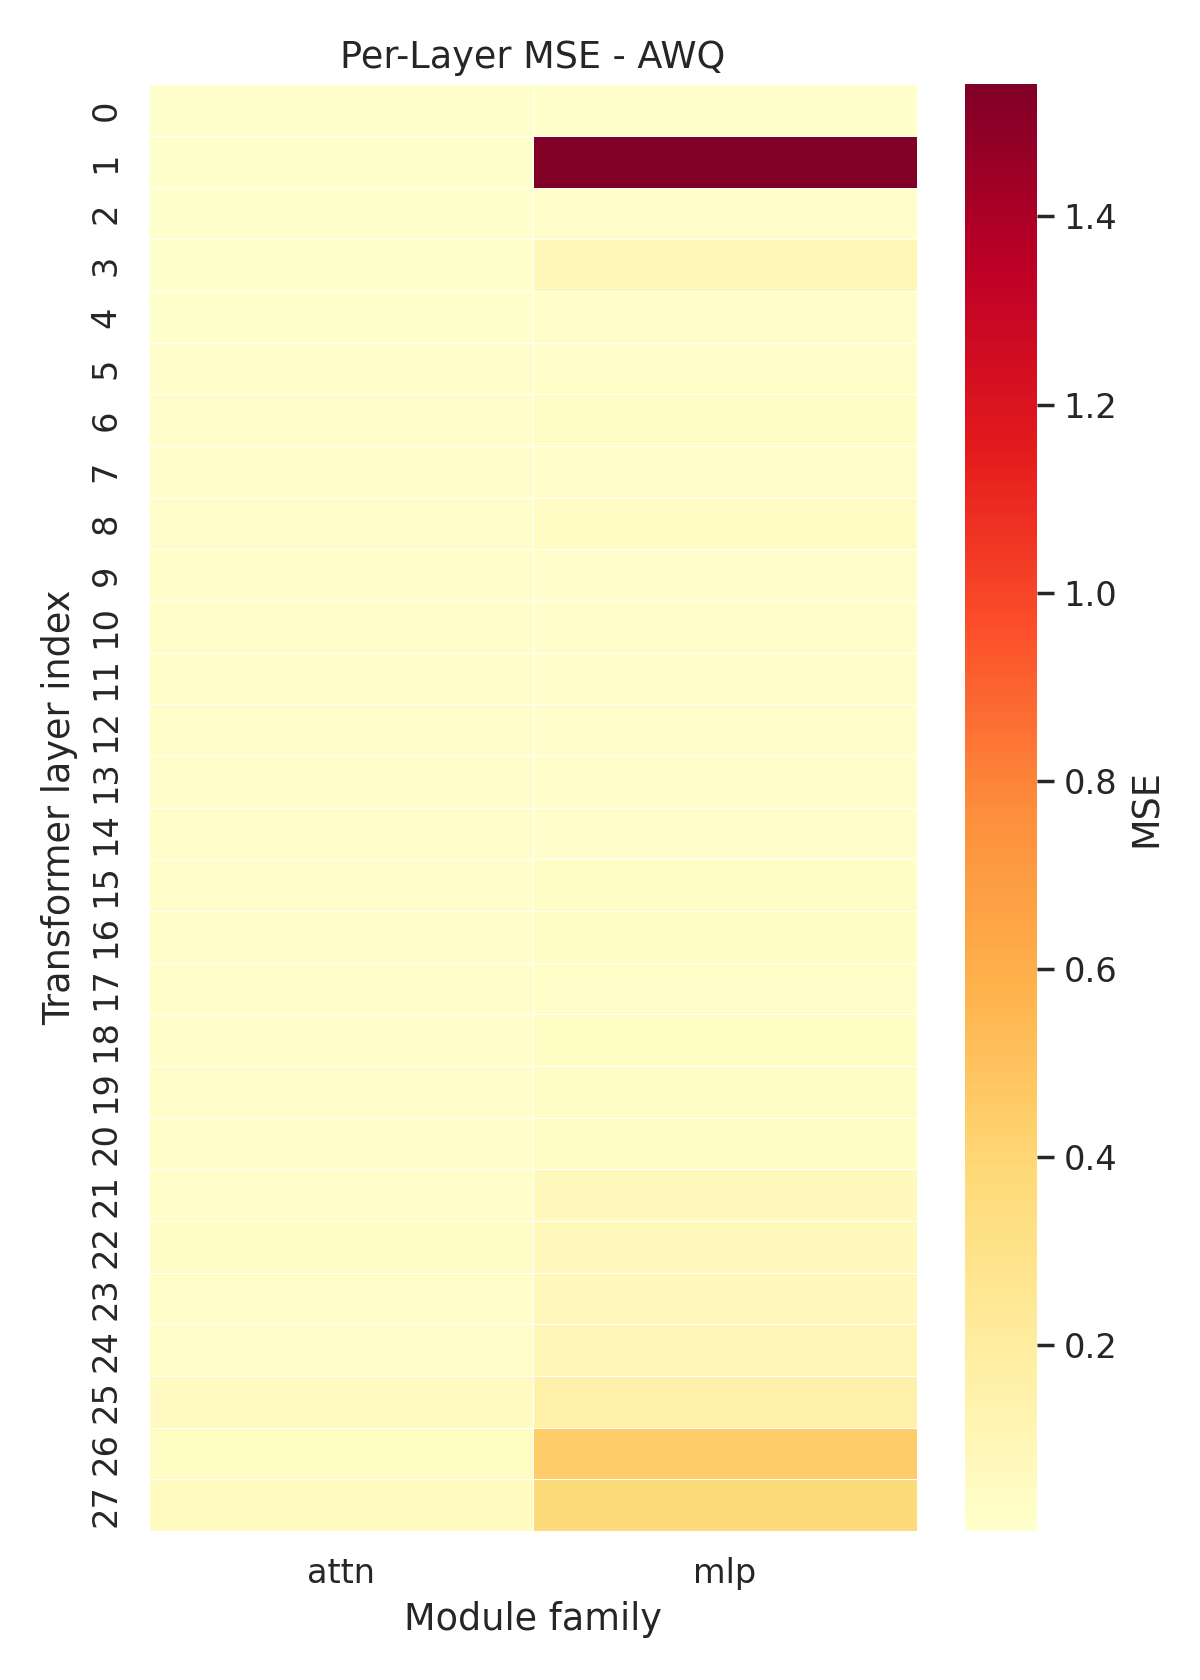

In [ ]:
if not layer_stats_df.empty:
    plot_layer_mse_heatmap(layer_stats_df, plots_dir)
    mse_png = plots_dir / f"layer_mse_{METHOD}.png"
    if mse_png.exists():
        display(Image(filename=str(mse_png)))
else:
    print("No layer stats data available for heatmap.")

---
## 10. Summary

Key results for AWQ (W4A16, `llm-compressor` `AWQModifier`) on Qwen2-1.5B.

In [ ]:
summary_cols = [
    "variant", "bytes_per_param_actual", "ppl",
    "gsm8k", "math", "arc_challenge", "gpqa", "score",
    "tok_s", "ms_per_token", "peak_vram_gb",
]
available = [c for c in summary_cols if c in eval_df.columns]
display(eval_df[available].round(3))

,variant,bytes_per_param_actual,ppl,gsm8k,math,arc_challenge,score,tok_s,ms_per_token,peak_vram_gb
0,attn_only_quant,2.028,12.545,0.6,0.0,0.7,0.7,11.521,86.799,5.712
1,mlp_only_quant,2.537,12.682,0.5,0.0,0.6,0.6,7.472,133.838,6.278
2,full_quant,2.807,13.017,0.6,0.0,0.6,0.6,5.282,189.306,6.377


In [ ]:
print(f"All results saved to: {Path(cfg['paths']['results_dir'])}")
print(f"All plots  saved to: {plots_dir}")
print("\nAWQ notebook complete.")

All results saved to: /content/results
All plots  saved to: /content/results/plots/awq

AWQ notebook complete.


# Presentation Visuals

In [ ]:
import pandas as pd

data = {
    'method': ['awq', 'awq', 'awq', 'awq'],
    'variant': ['baseline', 'attn_only_quant', 'full_quant', 'mlp_only_quant'],
    'bytes_per_param_actual': [0.000000, 1.849290, 0.733754, 0.881000],
    'ppl': [12.336393, 12.545359, 13.016976, 12.681935],
    'gsm8k': [0.55, 0.55, 0.60, 0.60],
    'arc_challenge': [0.658, 0.640, 0.626, 0.634],
    'score': [0.636426, 0.622011, 0.62085, 0.62272],
    'tok_s': [57.243537, 85.640604, 188.605806, 133.451949],
    'ms_per_tok': [3.632984, 5.640604, 6.377240, 6.278116],
    'peak_vram_gb': [5.590814, 5.711876, 6.377240, 6.278116]
}

df = pd.DataFrame(data)
order = ["baseline", "attn_only_quant", "mlp_only_quant", "full_quant"]
df = df.set_index("variant").loc[order].reset_index()
df

,variant,method,bytes_per_param_actual,ppl,gsm8k,arc_challenge,score,tok_s,ms_per_tok,peak_vram_gb
0,baseline,awq,0.000000,12.336393,0.55,0.658,0.636426,57.243537,3.632984,5.590814
1,attn_only_quant,awq,1.849290,12.545359,0.55,0.640,0.622011,85.640604,5.640604,5.711876
2,mlp_only_quant,awq,0.881000,12.681935,0.60,0.634,0.622720,133.451949,6.278116,6.278116
3,full_quant,awq,0.733754,13.016976,0.60,0.626,0.620850,188.605806,6.377240,6.377240


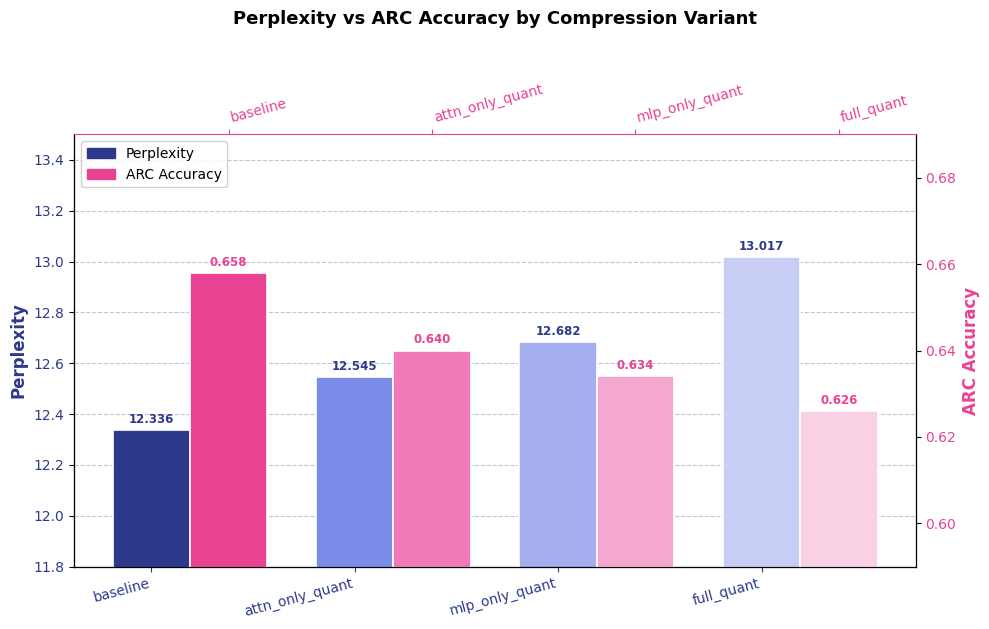

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

COLORS_PPL = ['#2d3a8c', '#7b8de8', '#a5aeef', '#c8cdf5']
COLORS_ARC = ['#e84393', '#f07ab8', '#f5a8cf', '#fad0e5']

variants = df['variant'].tolist()
x = np.arange(len(variants))
width = 0.38

fig, ax1 = plt.subplots(figsize=(10, 6))

# ── Perplexity bars (left y-axis) ────────────────────────────────────────────
bars1 = ax1.bar(x - width/2, df['ppl'], width, color=COLORS_PPL,
                edgecolor='white', linewidth=1.2, label='Perplexity', zorder=3)
ax1.set_ylabel('Perplexity', color='#2d3a8c', fontsize=12, fontweight='600')
ax1.tick_params(axis='y', labelcolor='#2d3a8c')
ax1.set_ylim(11.8, 13.5)
ax1.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8.5, color='#2d3a8c', fontweight='600')
ax1.spines[['top']].set_visible(False)
ax1.spines['left'].set_edgecolor('#2d3a8c')
ax1.yaxis.grid(True, linestyle='--', alpha=0.3, color='#2d3a8c')
ax1.set_axisbelow(True)

# ── ARC Accuracy bars (right y-axis) ─────────────────────────────────────────
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df['arc_challenge'], width, color=COLORS_ARC,
                edgecolor='white', linewidth=1.2, label='ARC Accuracy', zorder=3)
ax2.set_ylabel('ARC Accuracy', color='#e84393', fontsize=12, fontweight='600')
ax2.tick_params(axis='y', labelcolor='#e84393')
ax2.set_ylim(0.59, 0.69)
ax2.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8.5, color='#e84393', fontweight='600')
ax2.spines[['top']].set_visible(False)
ax2.spines['right'].set_edgecolor('#e84393')

# ── Top x-axis (ARC labels) ───────────────────────────────────────────────────
ax3 = ax1.twiny()
ax3.set_xlim(ax1.get_xlim())
ax3.set_xticks(x + width/2)
ax3.set_xticklabels(variants, rotation=15, ha='left', color='#e84393', fontsize=10, fontweight='500')
ax3.tick_params(axis='x', colors='#e84393')
ax3.spines['top'].set_edgecolor('#e84393')

# ── Bottom x-axis (PPL labels) ────────────────────────────────────────────────
ax1.set_xticks(x - width/2)
ax1.set_xticklabels(variants, rotation=15, ha='right', color='#2d3a8c', fontsize=10, fontweight='500')
ax1.tick_params(axis='x', colors='#2d3a8c')
ax1.spines['bottom'].set_edgecolor('#2d3a8c')

# ── Legend + title ────────────────────────────────────────────────────────────
fig.suptitle('Perplexity vs ARC Accuracy by Compression Variant',
             fontsize=13, fontweight='bold', y=1.04)

handles = [plt.Rectangle((0,0),1,1, color='#2d3a8c', label='Perplexity'),
           plt.Rectangle((0,0),1,1, color='#e84393', label='ARC Accuracy')]
ax1.legend(handles=handles, loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('overlayed_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

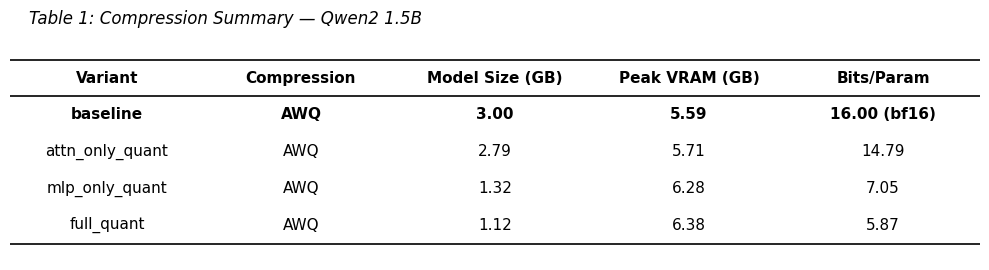

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis('off')

col_labels = ['Variant', 'Compression', 'Model Size (GB)', 'Peak VRAM (GB)', 'Bits/Param']

model_sizes = {
    'baseline':       '3.00',
    'attn_only_quant': '2.79',
    'mlp_only_quant':  '1.32',
    'full_quant':      '1.12',
}

bits_per_param = df['bytes_per_param_actual'].apply(lambda x: f"{x*8:.2f}" if x > 0 else "16.00 (bf16)")

table_data = list(zip(
    df['variant'],
    df['method'].str.upper(),
    df['variant'].map(model_sizes),
    df['peak_vram_gb'].apply(lambda x: f"{x:.2f}"),
    bits_per_param,
))

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('none')
    cell.set_facecolor('none')

for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_text_props(fontweight='bold')
    cell.visible_edges = 'TB'
    cell.set_edgecolor('black')
    cell.set_linewidth(1.2)

for i in range(len(table_data)):
    for j in range(len(col_labels)):
        cell = table[i+1, j]
        cell.visible_edges = ''
        if table_data[i][0] == 'baseline':
            cell.set_text_props(fontweight='bold')

for j in range(len(col_labels)):
    cell = table[len(table_data), j]
    cell.visible_edges = 'B'
    cell.set_edgecolor('black')
    cell.set_linewidth(1.2)

ax.set_title('Table 1: Compression Summary — Qwen2 1.5B',
             fontsize=12, fontweight='normal', fontstyle='italic',
             pad=14, loc='left', x=0.02)

plt.tight_layout()
plt.savefig('compression_table.png', dpi=150, bbox_inches='tight')
plt.show()